# Final Assignment Notebook: Economic Complexity Report

This notebook replicates the analysis for the final assignment using the imaginary countries and activities from the class exercises.  
It follows the same logic used in the provided exercise notebooks:

1. Network and bipartite visualization  
2. Descriptive statistics: diversity, specialization, and ubiquity  
3. Economic Complexity Index (ECI) and Product Complexity Index (PCI)  
4. Fitness and activity complexity  
5. Relatedness between activities using Product Space, Taxonomy, and Assist Matrix  
6. Diversification recommendations based on relatedness density

**Important note:** The class file `Fitness_Relatedness_Exercises.ipynb.json` says to use the updated `Mcp` matrix where The Stormland does **not** have activity `P7`. This notebook uses that updated matrix.

In [30]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)

## 1. Data setup

`Mcp` is a binary country-activity matrix. A value of **1** means the country is active in that activity, while **0** means it is not.

In [31]:
# Define Mcp, connecting imaginary countries and economic activities.
# This uses the updated matrix from the Fitness and Relatedness exercise notebook.
countries = [
    "Vale of Arryn", "The North", "The Riverlands", "Dorne",
    "The Stormland", "The Westerlands", "The Reach"
]
activities = [f"P{j}" for j in range(9)]

Mcp = np.array([
    [1, 0, 1, 0, 1, 1, 0, 0, 1],
    [0, 1, 1, 0, 0, 1, 1, 0, 0],
    [0, 1, 0, 1, 1, 0, 0, 0, 0],
    [1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 1],
    [0, 1, 1, 0, 1, 0, 1, 1, 1],
    [1, 1, 1, 1, 1, 0, 1, 1, 1]
])

R, C = Mcp.shape
M = pd.DataFrame(Mcp, index=countries, columns=activities)
M

,P0,P1,P2,P3,P4,P5,P6,P7,P8
Vale of Arryn,1,0,1,0,1,1,0,0,1
The North,0,1,1,0,0,1,1,0,0
The Riverlands,0,1,0,1,1,0,0,0,0
Dorne,1,0,1,0,0,0,0,0,0
The Stormland,0,0,0,0,0,1,1,0,1
The Westerlands,0,1,1,0,1,0,1,1,1
The Reach,1,1,1,1,1,0,1,1,1


## 2. Network and matrix visualization

The first graph shows the bipartite relationship between countries and activities. The matrix heatmap shows the same information in table form.

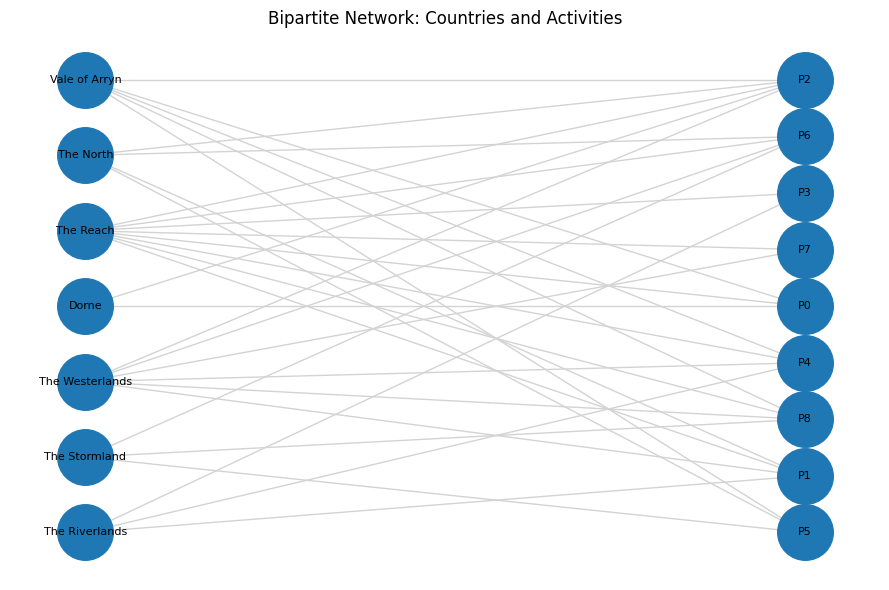

In [15]:
# Bipartite country-activity network
G = nx.Graph()
G.add_nodes_from(countries, bipartite=0)
G.add_nodes_from(activities, bipartite=1)

for i in range(R):
    for j in range(C):
        if Mcp[i, j] == 1:
            G.add_edge(countries[i], activities[j])

plt.figure(figsize=(9, 6))
pos = nx.bipartite_layout(G, countries)
nx.draw_networkx(G, pos, node_size=1600, font_size=8, edge_color="lightgray")
plt.title("Bipartite Network: Countries and Activities")
plt.axis("off")
plt.tight_layout()
plt.show()

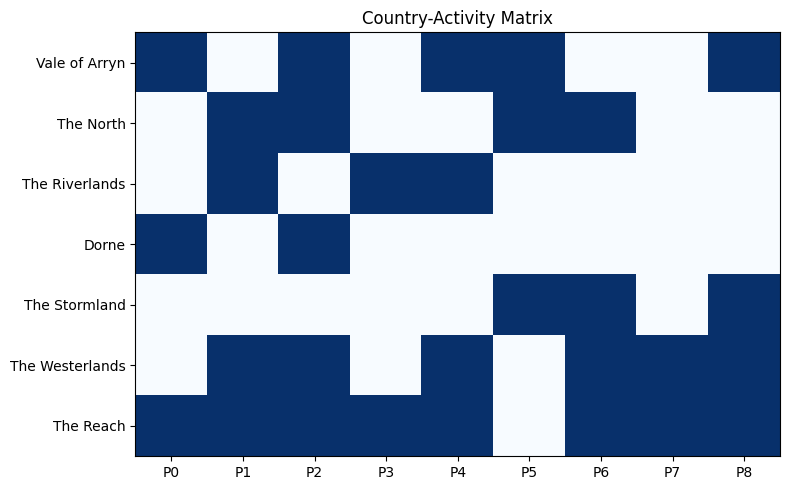

In [16]:
# Matrix visualization
fig, ax = plt.subplots(figsize=(8, 5))
ax.pcolor(Mcp, cmap="Blues")
ax.invert_yaxis()
ax.set_yticks([i + 0.5 for i in range(len(countries))])
ax.set_yticklabels(countries)
ax.set_xticks([j + 0.5 for j in range(len(activities))])
ax.set_xticklabels(activities)
ax.set_title("Country-Activity Matrix")
plt.tight_layout()
plt.show()

## 3. Descriptive statistics

- **Diversity** is the number of activities a country has.  
- **Specialization share** is diversity divided by the total number of possible activities.  
- **Ubiquity** is the number of countries that have a specific activity.  

A diversified country has many activities. A ubiquitous activity appears in many countries, so it is usually less exclusive.

In [17]:
diversification = Mcp.sum(axis=1)
ubiquity = Mcp.sum(axis=0)

country_stats = pd.DataFrame({
    "diversity": diversification,
    "specialization_share": diversification / C
}, index=countries).sort_values("diversity", ascending=False)

activity_stats = pd.DataFrame({
    "ubiquity": ubiquity,
    "activity_share": ubiquity / R
}, index=activities).sort_values("ubiquity", ascending=False)

print("Country descriptive statistics")
display(country_stats)

print("Activity ubiquity statistics")
display(activity_stats)

Country descriptive statistics


,diversity,specialization_share
The Reach,8,0.888889
The Westerlands,6,0.666667
Vale of Arryn,5,0.555556
The North,4,0.444444
The Riverlands,3,0.333333
The Stormland,3,0.333333
Dorne,2,0.222222


Activity ubiquity statistics


,ubiquity,activity_share
P2,5,0.714286
P8,4,0.571429
P1,4,0.571429
P4,4,0.571429
P6,4,0.571429
P0,3,0.428571
P5,3,0.428571
P3,2,0.285714
P7,2,0.285714


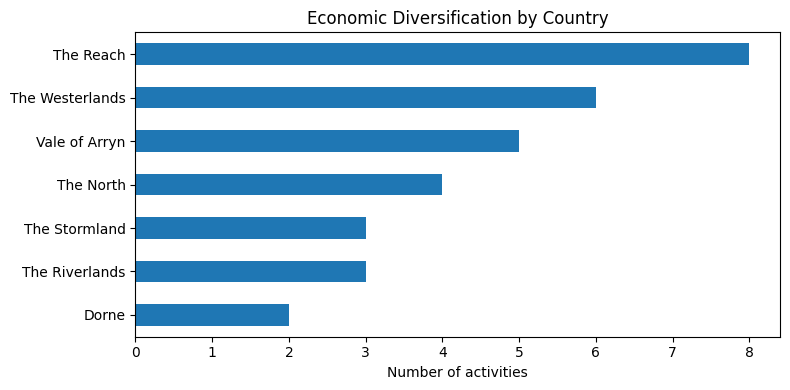

In [18]:
# Graph: country diversity
country_stats["diversity"].sort_values().plot(kind="barh", figsize=(8, 4))
plt.xlabel("Number of activities")
plt.title("Economic Diversification by Country")
plt.tight_layout()
plt.show()

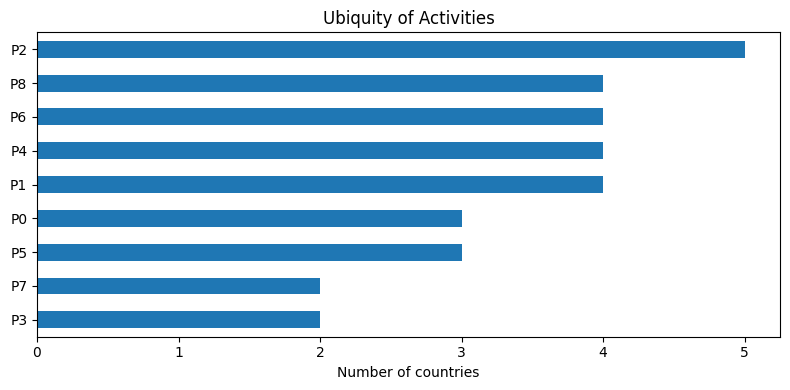

In [19]:
# Graph: activity ubiquity
activity_stats["ubiquity"].sort_values().plot(kind="barh", figsize=(8, 4))
plt.xlabel("Number of countries")
plt.title("Ubiquity of Activities")
plt.tight_layout()
plt.show()

### Interpretation for report section 1

The descriptive statistics show that The Reach is the most diversified economy because it has the highest number of activities. The Westerlands is also relatively diversified. Dorne has the lowest diversity, which suggests a narrower economic base. At the activity level, highly ubiquitous activities are shared by many countries, while low-ubiquity activities are more exclusive and may indicate more specialized capabilities.

## 4. ECI and PCI

This section follows the Economic Complexity Index exercise. It includes both:

1. Method of Reflections  
2. Eigenvalue approach  

The eigenvalue approach is used for the main ECI and PCI ranking.

In [20]:
def OneStep(Mcp, kc, kp):
    """One step of the Method of Reflections."""
    diversification = Mcp.sum(axis=1)
    ubiquity = Mcp.sum(axis=0)
    kc1 = Mcp.dot(kp) / diversification
    kp1 = Mcp.T.dot(kc) / ubiquity
    return kc1, kp1


def MethodOfReflections(Mcp, max_iterations=10):
    """Compute country and activity scores using the Method of Reflections."""
    ubiquity = np.sum(Mcp, axis=0)
    diversification = np.sum(Mcp, axis=1)

    kc = diversification / diversification.sum()
    kp = ubiquity / ubiquity.sum()

    for iteration in range(max_iterations):
        kc, kp = OneStep(Mcp, kc, kp)

    return (kc - kc.mean()) / kc.std(), (kp - kp.mean()) / kp.std()


kc_mor, kp_mor = MethodOfReflections(Mcp, max_iterations=10)

mor_country_table = pd.DataFrame({
    "diversity": diversification,
    "MoR_country_score": kc_mor
}, index=countries).sort_values("MoR_country_score", ascending=False)

mor_activity_table = pd.DataFrame({
    "ubiquity": ubiquity,
    "MoR_activity_score": kp_mor
}, index=activities).sort_values("MoR_activity_score", ascending=False)

display(mor_country_table)
display(mor_activity_table)

,diversity,MoR_country_score
The Riverlands,3,2.032391
The Reach,8,0.563539
The Westerlands,6,0.336084
The North,4,-0.504572
Vale of Arryn,5,-0.566523
Dorne,2,-0.673741
The Stormland,3,-1.187178


,ubiquity,MoR_activity_score
P5,3,1.429421
P0,3,0.814521
P2,5,0.628097
P8,4,0.589393
P6,4,0.519624
P7,2,-0.468579
P4,4,-0.738677
P1,4,-0.808447
P3,2,-1.965353


In [21]:
def zscore(x):
    """Normalize an array to mean 0 and standard deviation 1."""
    x = np.asarray(x, dtype=float)
    sd = x.std()
    if sd == 0:
        return x - x.mean()
    return (x - x.mean()) / sd

# Projecting matrices, following the class exercise notation
Ccc = np.matmul(
    np.array(Mcp.T / np.sum(Mcp, 1)).T,
    np.array(Mcp / np.sum(Mcp, 0)).T
)

Cpp = np.matmul(
    np.array(Mcp / np.sum(Mcp, 0)).T,
    np.array(Mcp.T / np.sum(Mcp, 1)).T
)

# Eigenvalue and eigenvector calculations
eigvalues_c, eigvectors_c = np.linalg.eig(Ccc)
eigvalues_p, eigvectors_p = np.linalg.eig(Cpp)

# ECI and PCI use the eigenvector related to the second largest eigenvalue
ECI = eigvectors_c[:, eigvalues_c.argsort()[-2]].real
PCI = eigvectors_p[:, eigvalues_p.argsort()[-2]].real

# Normalize
ECI = zscore(ECI)
PCI = zscore(PCI)

# The sign of eigenvectors is arbitrary. Orient the sign for easier interpretation.
if np.corrcoef(ECI, diversification)[0, 1] < 0:
    ECI = -ECI
if np.corrcoef(PCI, -ubiquity)[0, 1] < 0:
    PCI = -PCI

eci_table = pd.DataFrame({
    "diversity": diversification,
    "ECI": ECI
}, index=countries).sort_values("ECI", ascending=False)

pci_table = pd.DataFrame({
    "ubiquity": ubiquity,
    "PCI": PCI
}, index=activities).sort_values("PCI", ascending=False)

print("ECI ranking")
display(eci_table)

print("PCI ranking")
display(pci_table)

ECI ranking


,diversity,ECI
The Riverlands,3,2.054840
The Reach,8,0.544078
The Westerlands,6,0.304887
The North,4,-0.481505
Vale of Arryn,5,-0.561359
Dorne,2,-0.695802
The Stormland,3,-1.165138


PCI ranking


,ubiquity,PCI
P3,2,1.961043
P1,4,0.777844
P4,4,0.743803
P7,2,0.469049
P2,5,-0.558192
P6,4,-0.594818
P8,4,-0.628859
P0,3,-0.660084
P5,3,-1.509787


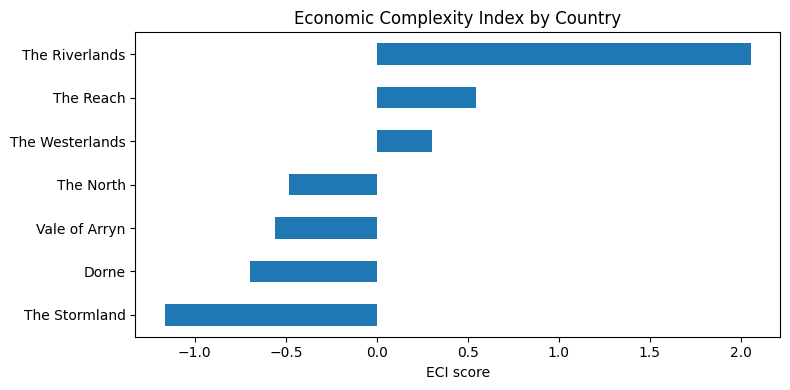

In [22]:
# Graph: ECI ranking
eci_table["ECI"].sort_values().plot(kind="barh", figsize=(8, 4))
plt.xlabel("ECI score")
plt.title("Economic Complexity Index by Country")
plt.tight_layout()
plt.show()

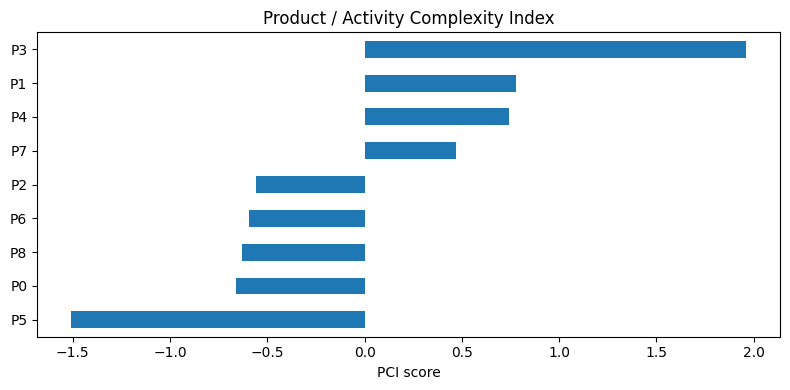

In [23]:
# Graph: PCI ranking
pci_table["PCI"].sort_values().plot(kind="barh", figsize=(8, 4))
plt.xlabel("PCI score")
plt.title("Product / Activity Complexity Index")
plt.tight_layout()
plt.show()

## 5. Fitness and Activity Complexity

This section follows the Fitness and Relatedness exercise. Fitness is iterative and nonlinear. It rewards countries that have many activities, especially activities that are not commonly found in low-fitness countries.

In [24]:
def fitCompOneStep(Mcp, Fitness):
    """One step of the Fitness-Complexity algorithm."""
    R, C = Mcp.shape
    Complexity = np.zeros(C)

    for p in range(C):
        with np.errstate(divide="ignore", invalid="ignore"):
            sumCT = Mcp[:, p] / Fitness
            sumCT[np.where(np.isnan(sumCT))] = 0.0
            denominator = np.sum(sumCT)
            Complexity[p] = 1.0 / denominator if denominator != 0 else 0

    Fitness = np.dot(Mcp, Complexity)
    return Fitness / np.mean(Fitness), Complexity / np.mean(Complexity)


def FitnessComplexity(Mcp, max_iterations=50):
    """Compute Fitness and Activity Complexity scores."""
    ubiquity = np.sum(Mcp, axis=0)
    diversification = np.sum(Mcp, axis=1)

    F = diversification / diversification.sum()
    Q = ubiquity / ubiquity.sum()

    for iteration in range(max_iterations):
        F, Q = fitCompOneStep(Mcp, F)

    return F / F.mean(), Q / Q.mean()

Fitness, Activity_Complexity = FitnessComplexity(Mcp, max_iterations=50)

fitness_table = pd.DataFrame({
    "diversity": diversification,
    "Fitness": Fitness,
    "ECI": ECI
}, index=countries).sort_values("Fitness", ascending=False)

activity_complexity_table = pd.DataFrame({
    "ubiquity": ubiquity,
    "Activity_Complexity": Activity_Complexity,
    "PCI": PCI
}, index=activities).sort_values("Activity_Complexity", ascending=False)

print("Fitness ranking")
display(fitness_table)

print("Activity complexity ranking")
display(activity_complexity_table)

Fitness ranking


,diversity,Fitness,ECI
The Reach,8,2.268388,0.544078
The Westerlands,6,1.618955,0.304887
The Riverlands,3,0.973295,2.054840
Vale of Arryn,5,0.784047,-0.561359
The North,4,0.633100,-0.481505
The Stormland,3,0.513044,-1.165138
Dorne,2,0.209171,-0.695802


Activity complexity ranking


,ubiquity,Activity_Complexity,PCI
P7,2,2.721071,0.469049
P3,2,1.961697,1.961043
P4,4,0.856882,0.743803
P1,4,0.785794,0.777844
P8,4,0.672483,-0.628859
P6,4,0.627903,-0.594818
P5,3,0.599553,-1.509787
P0,3,0.443328,-0.660084
P2,5,0.331290,-0.558192


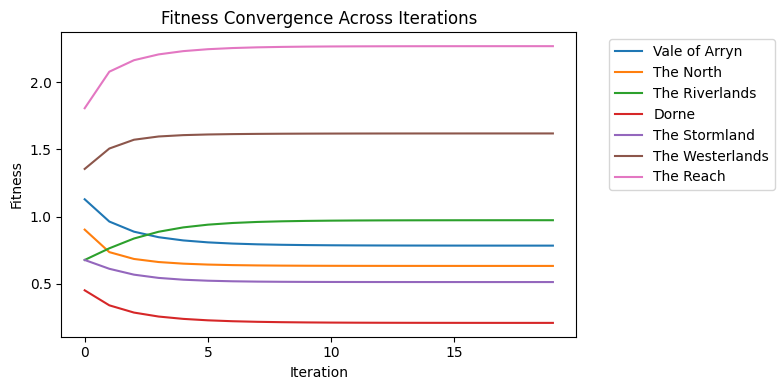

In [25]:
# Show convergence of Fitness across iterations
N = 20
Fseries = []
for iteration in range(N):
    F_temp, Q_temp = FitnessComplexity(Mcp, max_iterations=iteration)
    Fseries.append(F_temp)
Fseries = np.array(Fseries)

plt.figure(figsize=(8, 4))
plt.plot(Fseries)
plt.xlabel("Iteration")
plt.ylabel("Fitness")
plt.title("Fitness Convergence Across Iterations")
plt.xticks(range(0, N, 5), range(0, N, 5))
plt.legend(countries, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [26]:
# Comparison between ECI and Fitness
comparison_country = pd.DataFrame({
    "diversity": diversification,
    "ECI": ECI,
    "Fitness": Fitness,
    "ECI_rank": pd.Series(ECI, index=countries).rank(ascending=False).astype(int),
    "Fitness_rank": pd.Series(Fitness, index=countries).rank(ascending=False).astype(int)
}, index=countries).sort_values("ECI_rank")

comparison_country

,diversity,ECI,Fitness,ECI_rank,Fitness_rank
The Riverlands,3,2.054840,0.973295,1,3
The Reach,8,0.544078,2.268388,2,1
The Westerlands,6,0.304887,1.618955,3,2
The North,4,-0.481505,0.633100,4,5
Vale of Arryn,5,-0.561359,0.784047,5,4
Dorne,2,-0.695802,0.209171,6,7
The Stormland,3,-1.165138,0.513044,7,6


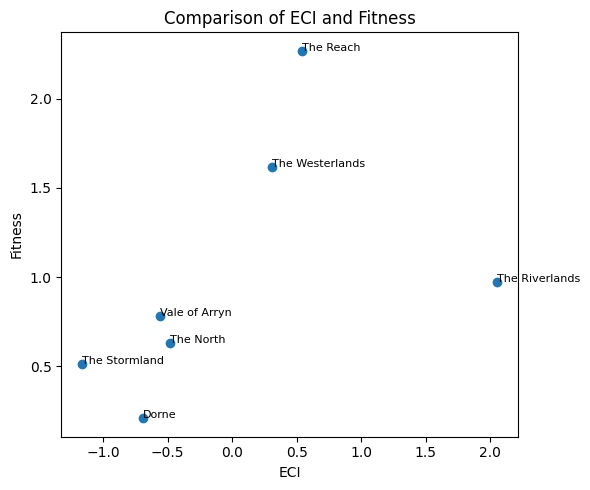

In [27]:
# Scatter comparison: ECI vs Fitness
plt.figure(figsize=(6, 5))
plt.scatter(comparison_country["ECI"], comparison_country["Fitness"])
for country in countries:
    plt.annotate(country, (comparison_country.loc[country, "ECI"], comparison_country.loc[country, "Fitness"]), fontsize=8)
plt.xlabel("ECI")
plt.ylabel("Fitness")
plt.title("Comparison of ECI and Fitness")
plt.tight_layout()
plt.show()

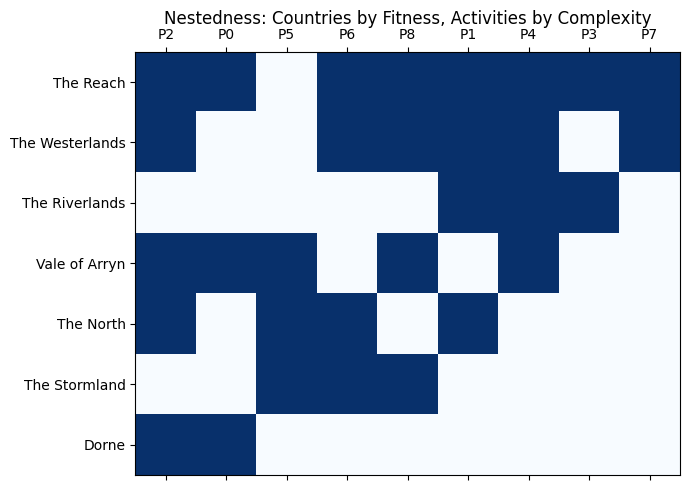

In [32]:
order_countries_f = np.argsort(Fitness)[::-1]
order_products_q = np.argsort(Activity_Complexity)

ordered_Mcp_fitness = np.zeros(np.shape(Mcp))
for c in range(len(order_countries_f)):
    for p in range(len(order_products_q)):
        ordered_Mcp_fitness[c, p] = Mcp[order_countries_f[c], order_products_q[p]]

fig, ax = plt.subplots(figsize=(7, 5))
ax.matshow(ordered_Mcp_fitness, cmap="Blues")
ax.set_yticks(range(R), [countries[i] for i in order_countries_f])
ax.set_xticks(range(C), [activities[i] for i in order_products_q])
ax.set_title("Nestedness: Countries by Fitness, Activities by Complexity", pad=20)
plt.tight_layout()
plt.show()

### Interpretation for report section 2

ECI and Fitness both aim to measure country complexity, but they do not use the same methodology. ECI is based on an eigenvector from the country-country projection matrix. Fitness is nonlinear and iterative, so it can be more sensitive to rare activities and nestedness. Because of this, country rankings may not be exactly the same. PCI and Activity Complexity also differ for similar reasons: PCI comes from the eigenvalue method, while Activity Complexity comes from the nonlinear Fitness algorithm.

## 6. Relatedness between activities

This section follows the Fitness and Relatedness exercise. Three relatedness matrices are included:

1. **Product Space**: symmetric co-occurrence normalized by ubiquity  
2. **Taxonomy**: symmetric relatedness adjusted by country diversification  
3. **Assist Matrix**: directional relatedness, so it is not symmetric  

The report can use the Taxonomy matrix because it is close to the class exercise and adjusts for country diversification.

In [33]:
def ProductSpace(Mcp):
    """Symmetric product-space relatedness based on co-occurrence and ubiquity."""
    Jpp = Mcp.T.dot(Mcp)
    ubiquity = Mcp.sum(0)
    ubiMat = np.tile(ubiquity, [Mcp.shape[1], 1])
    ubiMax = np.maximum(ubiMat, np.transpose(ubiMat)).astype(float)
    np.divide(np.ones_like(ubiMax, dtype=float), ubiMax, out=ubiMax, where=ubiMax != 0)
    return np.multiply(Jpp, ubiMax)


def Taxonomy(Mcp):
    """Symmetric relatedness adjusted by country diversification."""
    diversification = Mcp.sum(1)
    ubiquity = Mcp.sum(0)
    Jpp = Mcp.T.dot(np.diag(1 / diversification).dot(Mcp))
    ubiMat = np.tile(ubiquity, [Mcp.shape[1], 1])
    ubiMax = np.maximum(ubiMat, np.transpose(ubiMat)).astype(float)
    np.divide(np.ones_like(ubiMax, dtype=float), ubiMax, out=ubiMax, where=ubiMax != 0)
    return np.multiply(Jpp, ubiMax)


def AssistMatrix(Mcp):
    """Directional relatedness matrix. This matrix is not symmetric."""
    diversification = Mcp.sum(1)
    ubiquity = Mcp.sum(0)
    Jpp = Mcp.T.dot(np.diag(1 / diversification).dot(Mcp))
    ubiMat = np.tile(ubiquity, [Mcp.shape[1], 1]).astype(float)
    np.divide(np.ones_like(ubiMat, dtype=float), ubiMat, out=ubiMat, where=ubiMat != 0)
    return np.multiply(Jpp, ubiMat)


product_space = ProductSpace(Mcp)
taxonomy = Taxonomy(Mcp)
assist_matrix = AssistMatrix(Mcp)

# Set diagonal to zero for graphing and diversification analysis
taxonomy_no_diag = taxonomy.copy()
np.fill_diagonal(taxonomy_no_diag, 0)

product_space_df = pd.DataFrame(product_space, index=activities, columns=activities)
taxonomy_df = pd.DataFrame(taxonomy_no_diag, index=activities, columns=activities)
assist_df = pd.DataFrame(assist_matrix, index=activities, columns=activities)

print("Product Space matrix")
display(product_space_df)

print("Taxonomy matrix, diagonal removed")
display(taxonomy_df)

print("Assist Matrix")
display(assist_df)

Product Space matrix


,P0,P1,P2,P3,P4,P5,P6,P7,P8
P0,1.000000,0.25,0.6,0.333333,0.50,0.333333,0.25,0.333333,0.50
P1,0.250000,1.00,0.6,0.500000,0.75,0.250000,0.75,0.500000,0.50
P2,0.600000,0.60,1.0,0.200000,0.60,0.400000,0.60,0.400000,0.60
P3,0.333333,0.50,0.2,1.000000,0.50,0.000000,0.25,0.500000,0.25
P4,0.500000,0.75,0.6,0.500000,1.00,0.250000,0.50,0.500000,0.75
P5,0.333333,0.25,0.4,0.000000,0.25,1.000000,0.50,0.000000,0.50
P6,0.250000,0.75,0.6,0.250000,0.50,0.500000,1.00,0.500000,0.75
P7,0.333333,0.50,0.4,0.500000,0.50,0.000000,0.50,1.000000,0.50
P8,0.500000,0.50,0.6,0.250000,0.75,0.500000,0.75,0.500000,1.00


Taxonomy matrix, diagonal removed


,P0,P1,P2,P3,P4,P5,P6,P7,P8
P0,0.000000,0.031250,0.165000,0.041667,0.081250,0.066667,0.031250,0.041667,0.081250
P1,0.031250,0.000000,0.108333,0.114583,0.156250,0.062500,0.135417,0.072917,0.072917
P2,0.165000,0.108333,0.000000,0.025000,0.098333,0.090000,0.108333,0.058333,0.098333
P3,0.041667,0.114583,0.025000,0.000000,0.114583,0.000000,0.031250,0.062500,0.031250
P4,0.081250,0.156250,0.098333,0.114583,0.000000,0.050000,0.072917,0.072917,0.122917
P5,0.066667,0.062500,0.090000,0.000000,0.050000,0.000000,0.145833,0.000000,0.133333
P6,0.031250,0.135417,0.108333,0.031250,0.072917,0.145833,0.000000,0.072917,0.156250
P7,0.041667,0.072917,0.058333,0.062500,0.072917,0.000000,0.072917,0.000000,0.072917
P8,0.081250,0.072917,0.098333,0.031250,0.122917,0.133333,0.156250,0.072917,0.000000


Assist Matrix


,P0,P1,P2,P3,P4,P5,P6,P7,P8
P0,0.275000,0.031250,0.165000,0.062500,0.081250,0.066667,0.031250,0.062500,0.081250
P1,0.041667,0.218750,0.108333,0.229167,0.156250,0.083333,0.135417,0.145833,0.072917
P2,0.275000,0.135417,0.248333,0.062500,0.122917,0.150000,0.135417,0.145833,0.122917
P3,0.041667,0.114583,0.025000,0.229167,0.114583,0.000000,0.031250,0.062500,0.031250
P4,0.108333,0.156250,0.098333,0.229167,0.206250,0.066667,0.072917,0.145833,0.122917
P5,0.066667,0.062500,0.090000,0.000000,0.050000,0.261111,0.145833,0.000000,0.133333
P6,0.041667,0.135417,0.108333,0.062500,0.072917,0.194444,0.218750,0.145833,0.156250
P7,0.041667,0.072917,0.058333,0.062500,0.072917,0.000000,0.072917,0.145833,0.072917
P8,0.108333,0.072917,0.098333,0.062500,0.122917,0.177778,0.156250,0.145833,0.206250


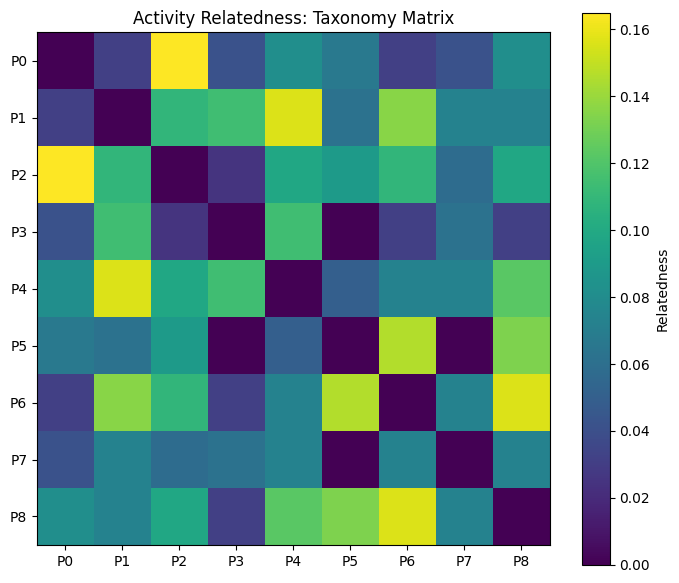

In [34]:
# Heatmap: Taxonomy relatedness matrix
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(taxonomy_df.values)
ax.set_title("Activity Relatedness: Taxonomy Matrix")
ax.set_xticks(range(C))
ax.set_yticks(range(C))
ax.set_xticklabels(activities)
ax.set_yticklabels(activities)
plt.colorbar(im, ax=ax, label="Relatedness")
plt.tight_layout()
plt.show()

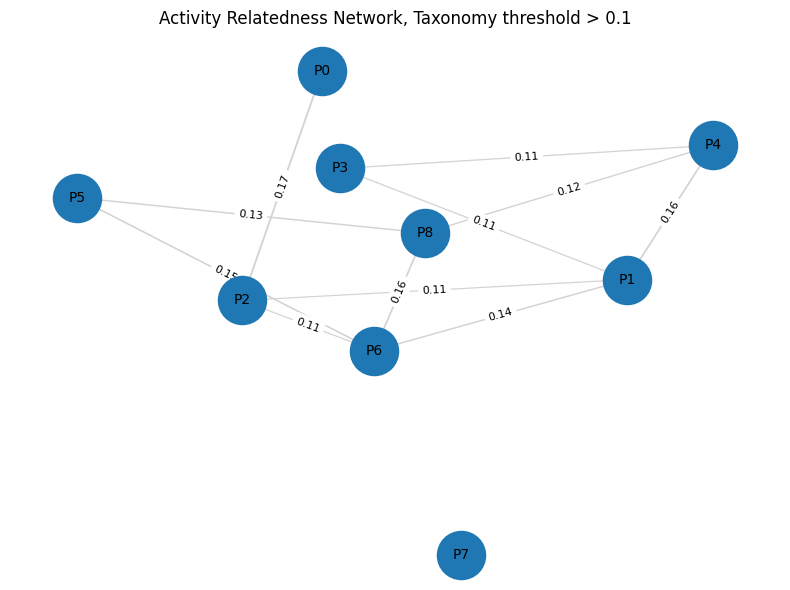

In [35]:
# Network diagram using Taxonomy relatedness
threshold = 0.10
Bpp = taxonomy_no_diag

G_related = nx.Graph()
G_related.add_nodes_from(activities)

for i in range(C):
    for j in range(i + 1, C):
        if Bpp[i, j] > threshold:
            G_related.add_edge(activities[i], activities[j], weight=Bpp[i, j])

pos = nx.spring_layout(G_related, seed=42, k=2 / np.sqrt(C))
edge_widths = [G_related[u][v]["weight"] * 8 for u, v in G_related.edges()]

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G_related, pos, node_size=1200)
nx.draw_networkx_labels(G_related, pos, font_size=10)
nx.draw_networkx_edges(G_related, pos, width=edge_widths, edge_color="lightgray")
edge_labels = {(u, v): f"{G_related[u][v]['weight']:.2f}" for u, v in G_related.edges()}
nx.draw_networkx_edge_labels(G_related, pos, edge_labels=edge_labels, font_size=8)
plt.title(f"Activity Relatedness Network, Taxonomy threshold > {threshold}")
plt.axis("off")
plt.tight_layout()
plt.show()

### Interpretation for report section 3

The relatedness analysis shows which activities are commonly connected in the same countries. A stronger link suggests that two activities may require similar or overlapping capabilities. This matters for diversification because a country is more likely to enter an activity that is close to what it already does. The heatmap shows the full relatedness structure, while the network diagram highlights the strongest links.

## 7. Diversification strategies

The opportunity score below is based on **density**. For each country and missing activity, the score measures how close the missing activity is to the country's current activity basket. A high score means the country already has related activities and may have an easier path into that new activity.

In [36]:
# Density score based on the Taxonomy relatedness matrix
relatedness_matrix = taxonomy_no_diag
relatedness_sum = relatedness_matrix.sum(axis=1)
relatedness_sum_safe = np.where(relatedness_sum == 0, 1, relatedness_sum)

density = np.zeros_like(Mcp, dtype=float)
for c in range(R):
    for p in range(C):
        density[c, p] = (Mcp[c, :] @ relatedness_matrix[p, :]) / relatedness_sum_safe[p]

opportunity_rows = []
for c_idx, country in enumerate(countries):
    for p_idx, activity in enumerate(activities):
        if Mcp[c_idx, p_idx] == 0:
            opportunity_rows.append({
                "country": country,
                "target_activity": activity,
                "density_score": density[c_idx, p_idx],
                "target_PCI": PCI[p_idx],
                "target_activity_complexity": Activity_Complexity[p_idx]
            })

opportunity_table = pd.DataFrame(opportunity_rows)
opportunity_table = opportunity_table.sort_values(
    ["country", "density_score", "target_PCI"], ascending=[True, False, False]
)

recommendations = opportunity_table.groupby("country").head(2).reset_index(drop=True)
recommendations

,country,target_activity,density_score,target_PCI,target_activity_complexity
0,Dorne,P5,0.285714,-1.509787,0.599553
1,Dorne,P8,0.233478,-0.628859,0.672483
2,The North,P8,0.599133,-0.628859,0.672483
3,The North,P0,0.544753,-0.660084,0.443328
4,The Reach,P5,1.000000,-1.509787,0.599553
5,The Riverlands,P7,0.458716,0.469049,2.721071
6,The Riverlands,P6,0.317680,-0.594818,0.627903
7,The Stormland,P2,0.394678,-0.558192,0.331290
8,The Stormland,P1,0.359116,0.777844,0.785794
9,The Westerlands,P3,0.900990,1.961043,1.961697


In [37]:
# Policy-style recommendations for the report
policy_recommendations = []
for country in countries:
    c_idx = countries.index(country)
    current = list(np.array(activities)[Mcp[c_idx] == 1])
    top_targets = recommendations[recommendations["country"] == country]["target_activity"].tolist()
    target_text = ", ".join(top_targets)
    current_text = ", ".join(current)
    policy_recommendations.append({
        "country": country,
        "current_activities": current_text,
        "recommended_targets": target_text,
        "recommendation_text": (
            f"{country} should prioritize {target_text} because these activities are closest "
            f"to its current activity basket ({current_text}). This strategy focuses first on "
            f"nearby activities before moving into less related sectors."
        )
    })

policy_table = pd.DataFrame(policy_recommendations)
policy_table

,country,current_activities,recommended_targets,recommendation_text
0,Vale of Arryn,"P0, P2, P4, P5, P8","P6, P1","Vale of Arryn should prioritize P6, P1 because..."
1,The North,"P1, P2, P5, P6","P8, P0","The North should prioritize P8, P0 because the..."
2,The Riverlands,"P1, P3, P4","P7, P6","The Riverlands should prioritize P7, P6 becaus..."
3,Dorne,"P0, P2","P5, P8","Dorne should prioritize P5, P8 because these a..."
4,The Stormland,"P5, P6, P8","P2, P1","The Stormland should prioritize P2, P1 because..."
5,The Westerlands,"P1, P2, P4, P6, P7, P8","P3, P5","The Westerlands should prioritize P3, P5 becau..."
6,The Reach,"P0, P1, P2, P3, P4, P6, P7, P8",P5,The Reach should prioritize P5 because these a...


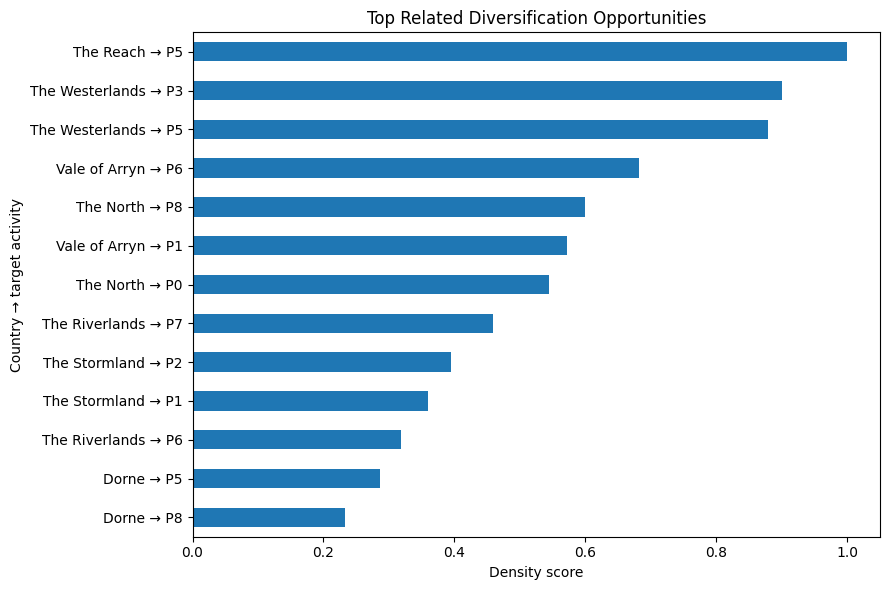

In [38]:
# Graph: top diversification opportunities
plot_recs = recommendations.copy()
plot_recs["label"] = plot_recs["country"] + " → " + plot_recs["target_activity"]
plot_recs.sort_values("density_score").plot(x="label", y="density_score", kind="barh", figsize=(9, 6), legend=False)
plt.xlabel("Density score")
plt.ylabel("Country → target activity")
plt.title("Top Related Diversification Opportunities")
plt.tight_layout()
plt.show()

### Interpretation for report section 4

The diversification strategy is based on relatedness density. Countries should not choose new activities randomly. Instead, they should prioritize activities that are close to their existing capabilities. The top recommendations identify realistic next steps for each country. Countries with low diversity, such as Dorne, should focus on nearby activities first. More diversified countries, such as The Reach and The Westerlands, may have more options because their existing activity baskets connect to more parts of the activity network.

## 8. Notebook conclusion

This notebook covers the minimum requirements of the final assignment. It includes descriptive statistics, ECI and PCI, Fitness and Activity Complexity, relatedness analysis, and diversification recommendations. The methods are aligned with the class exercise notebooks, especially the updated matrix and relatedness functions from the Fitness and Relatedness exercise.